# 18 — Semantic Similarity (KNN) Metadata Pipeline

**Core idea:** Instead of asking "Does this paper contain the keyword?", ask
"What training papers does this paper *look like*, and what metadata did those have?"

### How it works
1. **Embed** every training-set abstract (where ground-truth SDRF is known) using `all-MiniLM-L6-v2`.
2. **Embed** every test-set abstract.
3. For each test PXD, find the **K nearest training neighbours** by cosine similarity.
4. **Hard filter first** — only consider neighbours with the same organism (TaxID), so we never copy mouse metadata onto a human study.
5. For each SDRF column, take a **weighted majority vote** over the K neighbours' values (weight = similarity score). Only write when the winning value clears a confidence threshold.
6. Fall back to the graph/regex/PRIDE pipeline (notebook-17 style) for cells that are still empty.

### Why this beats rigid string-matching
- A paper on "Alzheimer's disease plasma proteomics" scores near other AD plasma studies → inherits `OrganismPart=blood plasma`, `Disease=Alzheimer disease`, `Sex=male and female` automatically.
- The synonym problem disappears: "elderly" and "senior" papers embed near each other; the known label for one transfers to the other.
- Silent metadata: prostate-cancer papers cluster together even without the word "male" → Sex is inferred from proximity.

### The catch (and fix)
The hard organism filter prevents cross-species contamination. If no filtered neighbour exceeds the similarity threshold, we write nothing and let the fallback layers fill in.

## 0. Imports & paths

In [62]:
import os, re, json, time
from collections import defaultdict, Counter
from pathlib import Path

import numpy as np
import pandas as pd
from tqdm import tqdm
import difflib
import requests
from functools import lru_cache

# sentence-transformers provides both the encoder and cosine_similarity
try:
    from sentence_transformers import SentenceTransformer
    from sklearn.metrics.pairwise import cosine_similarity
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                           'sentence-transformers', 'scikit-learn'])
    from sentence_transformers import SentenceTransformer
    from sklearn.metrics.pairwise import cosine_similarity

IS_KAGGLE = Path('/kaggle').exists()
if IS_KAGGLE:
    BASE_PATH = Path('/kaggle/input/harmonizing-the-data-of-your-data')
    OUT_PATH  = Path('/kaggle/working/submission_semantic.csv')
else:
    BASE_PATH = Path.cwd().parent / 'data'
    OUT_PATH  = Path.cwd().parent / 'outputs' / 'submission_semantic.csv'

OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
TRAIN_SDRF_DIR  = BASE_PATH / 'TrainingSDRFs'
TRAIN_TEXT_DIR  = BASE_PATH / 'TrainingPubText'
SAMPLE_SUB      = BASE_PATH / 'SampleSubmission.csv'
PRIDE_TIMEOUT   = 15
OLS_TIMEOUT     = 6
PX_TIMEOUT      = 12

_pubtext_candidates = [
    BASE_PATH / 'Test_PubText' / 'Test PubText',
    BASE_PATH / 'Test_PubText',
    BASE_PATH / 'TestPubText',
    BASE_PATH / 'Test PubText',
]
TEST_TEXT_DIR = next((p for p in _pubtext_candidates if p.exists()), _pubtext_candidates[0])

# ── tuneable knobs ────────────────────────────────────────────────────────────
K               = 5      # number of nearest neighbours to consider
SIM_THRESHOLD   = 0.70   # minimum similarity for a neighbour to vote
SOFT_ZONE_MAX   = 0.80   # sims in [SIM_THRESHOLD, SOFT_ZONE_MAX) need text confirmation
CONF_THRESHOLD  = 0.50   # weighted-majority fraction to accept a prediction
MODEL_NAME      = 'all-MiniLM-L6-v2'

print(f'Kaggle : {IS_KAGGLE}')
print(f'PubText: {TEST_TEXT_DIR} — exists: {TEST_TEXT_DIR.exists()}')
print(f'TrainText: {TRAIN_TEXT_DIR} — exists: {TRAIN_TEXT_DIR.exists()}')
print(f'SIM_THRESHOLD={SIM_THRESHOLD}  SOFT_ZONE_MAX={SOFT_ZONE_MAX}  CONF_THRESHOLD={CONF_THRESHOLD}  K={K}')


Kaggle : False
PubText: c:\Users\Sunny\OneDrive\Documents\Kaggle-Harmonizing-the-data-of-your-data\data\TestPubText — exists: True
TrainText: c:\Users\Sunny\OneDrive\Documents\Kaggle-Harmonizing-the-data-of-your-data\data\TrainingPubText — exists: True
SIM_THRESHOLD=0.7  SOFT_ZONE_MAX=0.8  CONF_THRESHOLD=0.5  K=5


## 1. Text helpers & ontology lookup tables

Shared with notebooks 16/17 — extract a clean string from a PubText JSON dict.

In [63]:
SECTIONS   = ['TITLE','ABSTRACT','METHODS','MATERIALS AND METHODS',
               'EXPERIMENTAL','SAMPLE PREPARATION','MASS SPECTROMETRY',
               'LC-MS','LC-MS/MS','PROTEIN DIGESTION','DATA ACQUISITION',
               'DATA ANALYSIS','CELL CULTURE']
METHOD_KWS = ['method','material','protocol','digest','spectr',
               'chromat','prep','enrichment','culture','experimental']


def get_text(pub_dict: dict) -> str:
    """Concatenate title + abstract + methods sections from a PubText JSON."""
    parts = []
    for key in ['TITLE', 'ABSTRACT'] + SECTIONS:
        v = pub_dict.get(key, '')
        if isinstance(v, list):
            v = ' '.join(str(x) for x in v)
        if v.strip():
            parts.append(v.strip())
    for key, v in pub_dict.items():
        if key.upper() in SECTIONS + ['TITLE', 'ABSTRACT']:
            continue
        if any(kw in key.lower() for kw in METHOD_KWS):
            if isinstance(v, list):
                v = ' '.join(str(x) for x in v)
            if v.strip():
                parts.append(v.strip())
    return ' '.join(parts)


def get_abstract(pub_dict: dict) -> str:
    """Return just title + abstract — shorter text for cleaner semantic similarity."""
    parts = []
    for key in ['TITLE', 'ABSTRACT']:
        v = pub_dict.get(key, '')
        if isinstance(v, list):
            v = ' '.join(str(x) for x in v)
        if v.strip():
            parts.append(v.strip())
    # fall back to full text if abstract is absent
    return ' '.join(parts) if parts else get_text(pub_dict)


# Organism normalisation (same as nb 17)
ORGANISM_ONT = {
    'homo sapiens': '9606 (Homo sapiens)', 'human': '9606 (Homo sapiens)',
    'humans': '9606 (Homo sapiens)', 'patient': '9606 (Homo sapiens)',
    'mus musculus': '10090 (Mus musculus)', 'mouse': '10090 (Mus musculus)',
    'mice': '10090 (Mus musculus)', 'murine': '10090 (Mus musculus)',
    'rattus norvegicus': '10116 (Rattus norvegicus)', 'rat': '10116 (Rattus norvegicus)',
    'saccharomyces cerevisiae': '4932 (Saccharomyces cerevisiae)',
    'yeast': '4932 (Saccharomyces cerevisiae)',
    'escherichia coli': '562 (Escherichia coli)',
    'e. coli': '562 (Escherichia coli)',
    'drosophila melanogaster': '7227 (Drosophila melanogaster)',
    'danio rerio': '7955 (Danio rerio)', 'zebrafish': '7955 (Danio rerio)',
    'arabidopsis thaliana': '3702 (Arabidopsis thaliana)',
    'sus scrofa': '9823 (Sus scrofa)', 'pig': '9823 (Sus scrofa)',
    'bos taurus': '9913 (Bos taurus)', 'bovine': '9913 (Bos taurus)',
    'gallus gallus': '9031 (Gallus gallus)', 'chicken': '9031 (Gallus gallus)',
    'caenorhabditis elegans': '6239 (Caenorhabditis elegans)',
    'xenopus laevis': '8355 (Xenopus laevis)',
    'macaca mulatta': '9544 (Macaca mulatta)',
    'oryctolagus cuniculus': '9986 (Oryctolagus cuniculus)',
    'rabbit': '9986 (Oryctolagus cuniculus)',
}


def infer_organism_from_text(text: str) -> str:
    """Guess organism from text using the ontology map. Returns canonical string or ''."""
    tl = text.lower()
    for key, val in sorted(ORGANISM_ONT.items(), key=lambda x: len(x[0]), reverse=True):
        if re.search(r'\b' + re.escape(key) + r'\b', tl):
            return val
    return ''


def _strip_wrapper(col):
    m = re.match(r'(?:characteristics|comment|factor\s*value)\[(.+?)\]', col, re.I)
    return m.group(1) if m else col


def _find_col(col: str, df_cols: set) -> str:
    """Locate a possibly-renamed column in a training SDRF."""
    if col in df_cols: return col
    base = re.sub(r'\.\d+$', '', col)
    if base in df_cols: return base
    stripped = _strip_wrapper(base)
    if stripped in df_cols: return stripped
    return ''


# ── OLS4 entity linking ───────────────────────────────────────────────────────
_ols_session = requests.Session()
_ols_session.headers.update({'Accept': 'application/json', 'User-Agent': 'SDRF-OLS/1.0'})


@lru_cache(maxsize=2000)
def ols_lookup(term, ontology):
    """Query OLS4 for a term in a specific ontology. Returns canonical NT=;AC= string or None.
    ontology: 'uberon', 'ms', 'unimod', 'pride'
    """
    if not term or str(term).strip().lower() in ('not applicable', 'na', 'n/a', ''):
        return None
    try:
        r = _ols_session.get(
            'https://www.ebi.ac.uk/ols4/api/search',
            params={'q': str(term).strip(), 'ontology': ontology,
                    'rows': 1, 'exact': 'false', 'fieldList': 'label,obo_id,short_form'},
            timeout=OLS_TIMEOUT
        )
        if r.status_code != 200: return None
        docs = r.json().get('response', {}).get('docs', [])
        if not docs: return None
        doc = docs[0]
        label  = doc.get('label', '')
        obo_id = doc.get('obo_id', '') or doc.get('short_form', '')
        if label and obo_id:
            if ontology == 'ms' and obo_id.startswith('MS:'):
                return f'AC={obo_id};NT={label}'
            return f'NT={label};AC={obo_id}'
        return None
    except Exception:
        return None


def ols_organism(name):
    """Resolve organism name to NCBI taxon ID format: '9606 (Homo sapiens)'."""
    LOCAL = {
        'homo sapiens': '9606 (Homo sapiens)', 'human': '9606 (Homo sapiens)',
        'humans': '9606 (Homo sapiens)',
        'mus musculus': '10090 (Mus musculus)', 'mouse': '10090 (Mus musculus)',
        'mice': '10090 (Mus musculus)', 'murine': '10090 (Mus musculus)',
        'rattus norvegicus': '10116 (Rattus norvegicus)', 'rat': '10116 (Rattus norvegicus)',
        'saccharomyces cerevisiae': '4932 (Saccharomyces cerevisiae)',
        'yeast': '4932 (Saccharomyces cerevisiae)',
        'escherichia coli': '562 (Escherichia coli)', 'e. coli': '562 (Escherichia coli)',
        'e.coli': '562 (Escherichia coli)',
        'drosophila melanogaster': '7227 (Drosophila melanogaster)',
        'danio rerio': '7955 (Danio rerio)', 'zebrafish': '7955 (Danio rerio)',
        'arabidopsis thaliana': '3702 (Arabidopsis thaliana)',
        'sus scrofa': '9823 (Sus scrofa)', 'pig': '9823 (Sus scrofa)', 'porcine': '9823 (Sus scrofa)',
        'bos taurus': '9913 (Bos taurus)', 'bovine': '9913 (Bos taurus)',
        'gallus gallus': '9031 (Gallus gallus)', 'chicken': '9031 (Gallus gallus)',
        'caenorhabditis elegans': '6239 (Caenorhabditis elegans)',
        'c. elegans': '6239 (Caenorhabditis elegans)',
        'xenopus laevis': '8355 (Xenopus laevis)',
        'macaca mulatta': '9544 (Macaca mulatta)',
        'rabbit': '9986 (Oryctolagus cuniculus)',
        'oryctolagus cuniculus': '9986 (Oryctolagus cuniculus)',
        'dog': '9615 (Canis lupus familiaris)',
    }
    n = str(name).lower().strip()
    for key in sorted(LOCAL, key=len, reverse=True):
        if key in n: return LOCAL[key]
    return None


def ols_tissue(name):
    """Resolve tissue/organ to UBERON canonical string; falls back to OLS4 API."""
    TISSUE_FAST = {
        'blood plasma': 'NT=blood plasma;AC=UBERON:0001969',
        'plasma': 'NT=blood plasma;AC=UBERON:0001969',
        'blood serum': 'NT=blood serum;AC=UBERON:0001977',
        'serum': 'NT=blood serum;AC=UBERON:0001977',
        'whole blood': 'NT=blood;AC=UBERON:0000178',
        'blood': 'NT=blood;AC=UBERON:0000178',
        'peripheral blood': 'NT=blood;AC=UBERON:0000178',
        'urine': 'NT=urine;AC=UBERON:0001088',
        'cerebrospinal fluid': 'NT=cerebrospinal fluid;AC=UBERON:0001359',
        'csf': 'NT=cerebrospinal fluid;AC=UBERON:0001359',
        'saliva': 'NT=saliva;AC=UBERON:0001836',
        'brain': 'NT=brain;AC=UBERON:0000955',
        'prefrontal cortex': 'NT=prefrontal cortex;AC=UBERON:0000451',
        'frontal cortex': 'NT=frontal cortex;AC=UBERON:0001870',
        'cerebral cortex': 'NT=cerebral cortex;AC=UBERON:0000956',
        'hippocampus': 'NT=hippocampal formation;AC=UBERON:0002421',
        'cerebellum': 'NT=cerebellum;AC=UBERON:0002037',
        'liver': 'NT=liver;AC=UBERON:0002107',
        'lung': 'NT=lung;AC=UBERON:0002048',
        'heart': 'NT=heart;AC=UBERON:0000948',
        'kidney': 'NT=kidney;AC=UBERON:0002113',
        'pancreas': 'NT=pancreas;AC=UBERON:0001264',
        'colon': 'NT=colon;AC=UBERON:0001155',
        'prostate': 'NT=prostate gland;AC=UBERON:0002367',
        'prostate gland': 'NT=prostate gland;AC=UBERON:0002367',
        'breast': 'NT=breast;AC=UBERON:0000310',
        'ovary': 'NT=ovary;AC=UBERON:0000992',
        'spleen': 'NT=spleen;AC=UBERON:0002106',
        'bone marrow': 'NT=bone marrow;AC=UBERON:0002371',
        'adipose tissue': 'NT=adipose tissue;AC=UBERON:0001013',
        'adipose': 'NT=adipose tissue;AC=UBERON:0001013',
        'skeletal muscle': 'NT=skeletal muscle;AC=UBERON:0001134',
        'muscle': 'NT=skeletal muscle;AC=UBERON:0001134',
        'skin': 'NT=skin of body;AC=UBERON:0002097',
        'thymus': 'NT=thymus;AC=UBERON:0002370',
        'lymph node': 'NT=lymph node;AC=UBERON:0000029',
        'testis': 'NT=testis;AC=UBERON:0000473',
        'retina': 'NT=retina;AC=UBERON:0000966',
        'pbmc': 'NT=peripheral blood mononuclear cell;AC=CL:0000057',
        'peripheral blood mononuclear': 'NT=peripheral blood mononuclear cell;AC=CL:0000057',
        'platelet': 'NT=platelet;AC=CL:0000233',
        'extracellular vesicle': 'NT=extracellular vesicle;AC=GO:0061695',
        'exosome': 'NT=extracellular vesicle;AC=GO:0061695',
    }
    n = str(name).lower().strip()
    for key in sorted(TISSUE_FAST, key=len, reverse=True):
        if key in n: return TISSUE_FAST[key]
    return ols_lookup(name, 'uberon')


def ols_instrument(name):
    """Resolve instrument to PSI-MS canonical AC=MS:XXXXXX;NT=Name; falls back to OLS4 API."""
    INSTRUMENT_FAST = {
        'q exactive hf-x': 'AC=MS:1003027;NT=Q Exactive HF-X',
        'q exactive hf': 'AC=MS:1002523;NT=Q Exactive HF',
        'q exactive plus': 'AC=MS:1002634;NT=Q Exactive Plus',
        'q-exactive plus': 'AC=MS:1002634;NT=Q Exactive Plus',
        'q exactive': 'AC=MS:1001911;NT=Q Exactive',
        'qexactive': 'AC=MS:1001911;NT=Q Exactive',
        'orbitrap astral': 'AC=MS:1003378;NT=Orbitrap Astral',
        'orbitrap fusion lumos': 'AC=MS:1002732;NT=Orbitrap Fusion Lumos',
        'fusion lumos': 'AC=MS:1002732;NT=Orbitrap Fusion Lumos',
        'orbitrap fusion': 'AC=MS:1002416;NT=Orbitrap Fusion',
        'orbitrap eclipse': 'AC=MS:1003029;NT=Orbitrap Eclipse',
        'orbitrap exploris 480': 'AC=MS:1003094;NT=Orbitrap Exploris 480',
        'exploris 480': 'AC=MS:1003094;NT=Orbitrap Exploris 480',
        'ltq orbitrap velos': 'AC=MS:1001742;NT=LTQ Orbitrap Velos',
        'ltq orbitrap elite': 'AC=MS:1001910;NT=LTQ Orbitrap Elite',
        'ltq orbitrap xl': 'AC=MS:1000556;NT=LTQ Orbitrap XL',
        'ltq orbitrap': 'AC=MS:1000449;NT=LTQ Orbitrap',
        'timstof pro 2': 'AC=MS:1003474;NT=timsTOF Pro 2',
        'timstof pro': 'AC=MS:1003231;NT=timsTOF Pro',
        'timstof': 'AC=MS:1002817;NT=timsTOF',
        'triple tof 6600': 'AC=MS:1000931;NT=TripleTOF 6600',
        'triple tof 5600': 'AC=MS:1000931;NT=TripleTOF 5600',
        'triple tof': 'AC=MS:1000931;NT=TripleTOF 6600',
        'impact ii': 'AC=MS:1002817;NT=impact II',
        'synapt g2': 'AC=MS:1002726;NT=Synapt G2-Si',
        'velos pro': 'AC=MS:1001909;NT=LTQ Velos Pro',
    }
    n = str(name).lower().strip()
    ac = re.search(r'AC=(MS:\d+)', name)
    nt_m = re.search(r'NT=([^;]+)', name)
    if ac and nt_m:
        return f'AC={ac.group(1).strip()};NT={nt_m.group(1).strip()}'
    for key in sorted(INSTRUMENT_FAST, key=len, reverse=True):
        if key in n: return INSTRUMENT_FAST[key]
    return ols_lookup(name, 'ms')


# ── Static term → SDRF ontology mapping ──────────────────────────────────────
# Tissue/organ terms use NT=;AC= format (UBERON ontology)
# Disease and CellLine stay as plain text — competition expects this
_FORMAT_AS_OLS_MAP = {
    'kidney':                         'NT=kidney;AC=UBERON:0002113',
    'blood serum':                    'NT=blood serum;AC=UBERON:0001977',
    'blood plasma':                   'NT=blood plasma;AC=UBERON:0001969',
    'plasma':                         'NT=blood plasma;AC=UBERON:0001969',
    'serum':                          'NT=blood serum;AC=UBERON:0001977',
    'brain':                          'NT=brain;AC=UBERON:0000955',
    'liver':                          'NT=liver;AC=UBERON:0002107',
    'lung':                           'NT=lung;AC=UBERON:0002048',
    'heart':                          'NT=heart;AC=UBERON:0000948',
    'bone marrow':                    'NT=bone marrow;AC=UBERON:0002371',
    'adipose tissue':                 'NT=adipose tissue;AC=UBERON:0001013',
    'frontal cortex':                 'NT=frontal cortex;AC=UBERON:0001870',
    'prefrontal cortex':              'NT=prefrontal cortex;AC=UBERON:0000451',
    'dorsolateral prefrontal cortex': 'NT=prefrontal cortex;AC=UBERON:0000451',
    'skin':                           'NT=skin of body;AC=UBERON:0002097',
    'prostate gland':                 'NT=prostate gland;AC=UBERON:0002367',
    'extracellular vesicle':          'NT=extracellular vesicle;AC=GO:0061695',
    'breast':                         'NT=breast;AC=UBERON:0000310',
    # NOTE: Disease and CellLine are NOT in this map
    # They use plain text format e.g. 'COVID-19', 'HEK293T'
}


def format_as_ols(text: str, column_name: str = '') -> str:
    """Map a common proteomics term to its official SDRF NT=...;AC=... format.

    Values already in NT=;AC= format or equal to 'Not Applicable' are
    returned unchanged.  Lookup is case-insensitive.
    """
    if not isinstance(text, str):
        return str(text)
    # Pass-through: already formatted or explicitly not applicable
    stripped = text.strip()
    if stripped == 'Not Applicable' or (';AC=' in stripped and stripped.startswith('NT=')):
        return stripped
    key = stripped.lower()
    if key in _FORMAT_AS_OLS_MAP:
        return _FORMAT_AS_OLS_MAP[key]
    return stripped


print('Text helpers, OLS functions & ontologies loaded.')


Text helpers, OLS functions & ontologies loaded.


## 2. Load training SDRFs → anchor metadata

For each training PXD we collect:
- `anchor_text[pxd]` — the abstract/title used for embedding
- `anchor_meta[pxd]` — a dict of `col → [list of canonical values]` from the SDRF
- `anchor_organism[pxd]` — inferred organism (for the hard filter)

Training SDRFs are ground truth — no guessing involved.

In [64]:
sample_sub  = pd.read_csv(SAMPLE_SUB)
target_cols = [c for c in sample_sub.columns
               if c not in ('ID', 'PXD', 'Raw Data File', 'Usage')]

# ── counters for the fallback majority-vote (kept from nb 17) ─────────────────
col_counters = {col: Counter() for col in target_cols}
col_vocab    = defaultdict(set)   # per-column training vocabulary for fuzzy_snap
train_pxd_sdrf: dict[str, dict] = {}

train_files = []
if TRAIN_SDRF_DIR.exists():
    train_files = (list(TRAIN_SDRF_DIR.glob('*.tsv')) +
                   list(TRAIN_SDRF_DIR.glob('*.csv')))

for fp in train_files:
    sep = '\t' if fp.suffix == '.tsv' else ','
    try:
        df = pd.read_csv(fp, low_memory=False, sep=sep)
    except Exception:
        continue
    pxd = fp.stem.replace('Harmonized_', '').replace('_cleaned.sdrf', '').split('.')[0]
    pxd_vals: dict[str, list] = {}
    for col in target_cols:
        mc = _find_col(col, set(df.columns))
        if mc:
            vals = df[mc].dropna().astype(str)
            vals = vals[~vals.str.lower().isin(['not applicable', 'n/a', 'na', ''])]
            col_counters[col].update(vals.tolist())
            col_vocab[re.sub(r'\.\d+$', '', col)].update(vals.tolist())
            uniq = list(vals.unique())
            if uniq:
                pxd_vals[col] = uniq
    train_pxd_sdrf[pxd] = pxd_vals

global_modes: dict[str, str] = {}
non_na_ratio: dict[str, float] = {}
n_train = max(len(train_files), 1)
for col in target_cols:
    total = sum(col_counters[col].values())
    global_modes[col] = (col_counters[col].most_common(1)[0][0]
                         if total > 0 else 'Not Applicable')
    non_na_ratio[col] = total / n_train if total > 0 else 0.0

NO_FALLBACK = {
    'Characteristics[SyntheticPeptide]', 'Characteristics[PooledSample]',
    'Characteristics[Bait]', 'Characteristics[TumorSize]', 'Characteristics[GrowthRate]',
    'Characteristics[SamplingTime]', 'Characteristics[Time]', 'Characteristics[Compound]',
    'Characteristics[ConcentrationOfCompound]', 'Characteristics[Treatment]',
    'Characteristics[DiseaseTreatment]', 'Characteristics[Depletion]',
    'Characteristics[CellPart]', 'Characteristics[Age]', 'Characteristics[BMI]',
    'Characteristics[AncestryCategory]', 'Characteristics[Disease]',
    'Characteristics[CellLine]', 'Characteristics[CellType]',
    'FactorValue[Bait]', 'FactorValue[CellPart]', 'FactorValue[Treatment]',
    'FactorValue[Disease]', 'FactorValue[Compound]',
    'FactorValue[ConcentrationOfCompound].1', 'FactorValue[GeneticModification]',
    'FactorValue[Temperature]', 'FactorValue[FractionIdentifier]',
}

print(f'Train SDRFs : {len(train_files)}')
print(f'Train PXDs  : {len(train_pxd_sdrf)}')
print(f'Target cols : {len(target_cols)}')

Train SDRFs : 103
Train PXDs  : 103
Target cols : 77


## 3. Load paper texts

We need:
- **Training** abstracts — one per anchor PXD (from `TrainingPubText/`)
- **Test** abstracts — one per test PXD (from `TestPubText/`) 

The bulk PubText.json file is also handled as a fallback.

In [65]:
def load_pub_texts(text_dir: Path) -> dict[str, dict]:
    """Load all PXD→pubtext dicts from a directory of *_PubText.json files."""
    docs: dict[str, dict] = {}
    if not text_dir.exists():
        return docs
    # bulk file first
    bulk = text_dir / 'PubText.json'
    if bulk.exists():
        try:
            bulk_d = json.loads(bulk.read_text(encoding='utf-8', errors='replace'))
            for pxd, d in bulk_d.items():
                if isinstance(d, dict) and d:
                    docs[pxd] = d
        except Exception:
            pass
    # individual files (override bulk)
    for fp in sorted(text_dir.glob('*.json')):
        if fp.name == 'PubText.json':
            continue
        pxd = fp.stem.split('_')[0]
        try:
            d = json.loads(fp.read_text(encoding='utf-8', errors='replace'))
            if d:
                docs[pxd] = d
        except Exception:
            pass
    return docs


train_docs = load_pub_texts(TRAIN_TEXT_DIR)
test_docs  = load_pub_texts(TEST_TEXT_DIR)

# Build the raw→PXD mapping for the test set
pxd_to_raws: dict[str, list] = {}
for _, row in sample_sub.iterrows():
    pxd_to_raws.setdefault(row['PXD'], []).append(row['Raw Data File'])

print(f'Training paper texts : {len(train_docs)}')
print(f'Test     paper texts : {len(test_docs)}')
print(f'Test PXDs in sub     : {len(pxd_to_raws)}')

Training paper texts : 103
Test     paper texts : 15
Test PXDs in sub     : 15


## 4. Embed all abstracts

`all-MiniLM-L6-v2` is 80 MB, runs on CPU in ~1–2 s per batch.  
We use **title + abstract only** (not the full methods section) to keep the vectors
focused on *what the study is about*, not on instrument model names.

Embeddings are cached to disk so re-runs are instant.

In [66]:
EMBED_CACHE = OUT_PATH.parent / 'embeddings_semantic18.npz'

# Collect ordered lists so indices are stable
train_pxds_with_text = [p for p in sorted(train_pxd_sdrf.keys()) if p in train_docs]
test_pxds_with_text  = [p for p in sorted(pxd_to_raws.keys())    if p in test_docs]

train_abstracts = [get_abstract(train_docs[p]) for p in train_pxds_with_text]
test_abstracts  = [get_abstract(test_docs[p])  for p in test_pxds_with_text]

print(f'Anchor PXDs (train w/ text) : {len(train_pxds_with_text)}')
print(f'Query  PXDs (test  w/ text) : {len(test_pxds_with_text)}')

if EMBED_CACHE.exists():
    print('Loading embeddings from cache...')
    cache = np.load(EMBED_CACHE)
    train_embs = cache['train']
    test_embs  = cache['test']
    print(f'  train: {train_embs.shape}  test: {test_embs.shape}')
else:
    print(f'Encoding with {MODEL_NAME} (first run — downloads ~80 MB)...')
    encoder = SentenceTransformer(MODEL_NAME)
    train_embs = encoder.encode(train_abstracts, batch_size=32,
                                show_progress_bar=True, normalize_embeddings=True)
    test_embs  = encoder.encode(test_abstracts,  batch_size=32,
                                show_progress_bar=True, normalize_embeddings=True)
    np.savez(EMBED_CACHE, train=train_embs, test=test_embs)
    print(f'Saved embeddings → {EMBED_CACHE}')
    del encoder  # free memory

print('Done.')

Anchor PXDs (train w/ text) : 103
Query  PXDs (test  w/ text) : 15
Loading embeddings from cache...
  train: (103, 384)  test: (15, 384)
Done.


## 5. Build the similarity matrix & KNN index

`cosine_similarity(test_embs, train_embs)` returns an `(n_test × n_train)` matrix.
Each row is one test PXD; each column is one train PXD.  
The value is in `[-1, 1]`; normalised embeddings make this equivalent to dot product.

In [67]:
# sim_matrix[i, j] = cosine similarity between test_pxds[i] and train_pxds[j]
sim_matrix = cosine_similarity(test_embs, train_embs)  # (n_test, n_train)

print(f'Similarity matrix : {sim_matrix.shape}')
print(f'  Min  : {sim_matrix.min():.4f}')
print(f'  Max  : {sim_matrix.max():.4f}')
print(f'  Mean : {sim_matrix.mean():.4f}')

# Preview: top 3 neighbours for the first few test PXDs
print('\n=== Top-3 neighbours (no organism filter yet) ===')
for i, test_pxd in enumerate(test_pxds_with_text[:5]):
    row = sim_matrix[i]
    top3 = row.argsort()[::-1][:3]
    neighbours = [(train_pxds_with_text[j], row[j]) for j in top3]
    print(f'  {test_pxd}: ' + ' | '.join(f'{p}({s:.3f})' for p, s in neighbours))

Similarity matrix : (15, 103)
  Min  : -0.0408
  Max  : 0.7427
  Mean : 0.2968

=== Top-3 neighbours (no organism filter yet) ===
  PXD004010: PXD004143(0.721) | PXD007160(0.640) | PXD001819(0.639)
  PXD016436: PXD001819(0.585) | PXD012431(0.575) | PXD004683(0.537)
  PXD019519: PXD010429(0.536) | PXD010357(0.536) | PXD013923(0.504)
  PXD025663: PXD010603(0.601) | PXD012131(0.601) | PXD014557(0.493)
  PXD040582: PXD018357(0.482) | PXD005539(0.438) | PXD015957(0.408)


## 6. Organism inference for the hard filter

We infer organism from text (not from the SDRF) for both train and test PXDs.  
This is the "guard rail" that stops mouse metadata from being copied to a human study.

In [68]:
# For anchors: prefer the SDRF ground truth, fall back to text inference
def get_organism_from_sdrf(pxd: str) -> str:
    meta = train_pxd_sdrf.get(pxd, {})
    vals = meta.get('Characteristics[Organism]', [])
    return vals[0] if vals else ''


train_organisms = {}
for p in train_pxds_with_text:
    org = get_organism_from_sdrf(p)
    # Normalize raw SDRF organism to same format as infer_organism_from_text output
    norm = ols_organism(org) if org else ''
    if not norm:
        norm = infer_organism_from_text(get_abstract(train_docs[p]))
    train_organisms[p] = norm

test_organisms = {}
for p in test_pxds_with_text:
    test_organisms[p] = infer_organism_from_text(get_abstract(test_docs[p]))

# Summary
from collections import Counter as _C
print('Training organism distribution (normalised):')
for org, n in _C(train_organisms.values()).most_common():
    print(f'  {str(org)[:45]:<45} : {n}')
print('\nTest organism distribution (text inference):')
for org, n in _C(test_organisms.values()).most_common():
    print(f'  {str(org)[:45]:<45} : {n}')


Training organism distribution (normalised):
  9606 (Homo sapiens)                           : 82
                                                : 11
  10090 (Mus musculus)                          : 6
  4932 (Saccharomyces cerevisiae)               : 3
  562 (Escherichia coli)                        : 1

Test organism distribution (text inference):
  9606 (Homo sapiens)                           : 7
                                                : 3
  10090 (Mus musculus)                          : 3
  562 (Escherichia coli)                        : 1
  10116 (Rattus norvegicus)                     : 1


## 7. Weighted KNN vote function

For a given test PXD and SDRF column:
1. Filter neighbours to same-organism anchors with similarity ≥ `SIM_THRESHOLD`.
2. Accumulate `similarity` as vote-weight for each candidate value.
3. Accept the top value if it holds > `CONF_THRESHOLD` of the total weight.

In [69]:
# Pre-compute index maps
_train_idx = {p: i for i, p in enumerate(train_pxds_with_text)}
_test_idx  = {p: i for i, p in enumerate(test_pxds_with_text)}


def _knn_keyword(value: str) -> str:
    """Extract a short searchable keyword from an SDRF value for text confirmation."""
    v = str(value).strip()
    # Strip NT=...;AC=... wrappers — keep the NT= label
    nt_m = re.search(r'NT=([^;]+)', v, re.I)
    if nt_m:
        v = nt_m.group(1).strip()
    # Strip remaining AC=... fragments
    v = re.sub(r'AC=\S+', '', v, flags=re.I).strip('; ').strip()
    return v.lower()


def knn_predict(test_pxd: str, col: str,
                k: int = K,
                sim_thresh: float = SIM_THRESHOLD,
                conf_thresh: float = CONF_THRESHOLD) -> list[str]:
    """
    Return a list of predicted values for `col` for `test_pxd`.

    Soft-zone double-check: neighbours with similarity in
    [sim_thresh, SOFT_ZONE_MAX) are only counted if the predicted
    value's keyword also appears in the test PXD's abstract/title text.
    """
    if test_pxd not in _test_idx:
        return []  # no embedding for this PXD

    qi = _test_idx[test_pxd]
    query_org = test_organisms.get(test_pxd, '')
    row = sim_matrix[qi]  # similarities to all train anchors

    # Pre-compute test abstract text once (for soft-zone checks)
    test_text = get_abstract(test_docs.get(test_pxd, {})).lower()
    has_text = len(test_text.strip()) > 50  # PXDs with no paper
    # For no-text PXDs, require very high similarity to trust KNN
    effective_thresh = sim_thresh if has_text else max(sim_thresh, 0.85)

    # Sort descending
    ranked = row.argsort()[::-1]

    vote_weights: Counter = Counter()
    total_weight = 0.0
    neighbours_used = 0

    for j in ranked:
        if neighbours_used >= k:
            break
        sim = float(row[j])
        if sim < effective_thresh:
            break  # sorted, so all remaining are below threshold

        anchor_pxd = train_pxds_with_text[j]

        # ── hard organism filter ──────────────────────────────────────────────
        anchor_org = train_organisms.get(anchor_pxd, '')
        if query_org and anchor_org and query_org != anchor_org:
            continue  # different species — skip

        # ── collect values for this column from the anchor ───────────────────
        anchor_meta = train_pxd_sdrf.get(anchor_pxd, {})
        vals = anchor_meta.get(col, [])
        if not vals:
            continue

        # ── soft-zone double-check ────────────────────────────────────────────
        # Neighbours in the "soft zone" [sim_thresh, SOFT_ZONE_MAX) must have
        # their predicted keyword confirmed by the test PXD's abstract/title.
        if sim_thresh <= sim < SOFT_ZONE_MAX:
            confirmed = [v for v in vals if _knn_keyword(v) and _knn_keyword(v) in test_text]
            if not confirmed:
                continue  # no value passed the text check — skip this neighbour
            vals = confirmed

        # Vote: distribute similarity weight equally among values
        per_val = sim / len(vals)
        for v in vals:
            v = str(v).strip()
            if v.lower() not in ('not applicable', 'n/a', 'na', ''):
                vote_weights[v] += per_val
                total_weight += per_val
        neighbours_used += 1

    if not vote_weights or total_weight == 0:
        return []

    # Accept values whose combined weight exceeds the confidence threshold
    best_val, best_weight = vote_weights.most_common(1)[0]
    if best_weight / total_weight < conf_thresh:
        return []

    return [best_val]


print('KNN predict function defined (with soft-zone double-check).')


KNN predict function defined (with soft-zone double-check).


## 8. Diagnostic: KNN predictions for all test PXDs

Before building the submission, inspect what the KNN layer alone would predict
for the key biological columns.

In [70]:
DIAG_COLS = [
    'Characteristics[Organism]',
    'Characteristics[OrganismPart]',
    'Characteristics[CellLine]',
    'Characteristics[Disease]',
    'Characteristics[Sex]',
    'Characteristics[Label]',
    'Comment[Instrument]',
]

rows = []
for test_pxd in test_pxds_with_text:
    row = {'PXD': test_pxd,
           'organism_inferred': test_organisms.get(test_pxd, '(none)')}
    for col in DIAG_COLS:
        short = col.replace('Characteristics[', '').replace('Comment[', '').rstrip(']')
        preds = knn_predict(test_pxd, col)
        row[short] = preds[0][:50] if preds else '—'
    rows.append(row)

diag_df = pd.DataFrame(rows)
print(diag_df.to_string(index=False))

      PXD         organism_inferred Organism OrganismPart CellLine Disease Sex Label Instrument
PXD004010       9606 (Homo sapiens)        —            —        —       —   —     —          —
PXD016436                                  —            —        —       —   —     —          —
PXD019519       9606 (Homo sapiens)        —            —        —       —   —     —          —
PXD025663       9606 (Homo sapiens)        —            —        —       —   —     —          —
PXD040582       9606 (Homo sapiens)        —            —        —       —   —     —          —
PXD050621    562 (Escherichia coli)        —            —        —       —   —     —          —
PXD061009                                  —            —        —       —   —     —          —
PXD061090 10116 (Rattus norvegicus)        —            —        —       —   —     —          —
PXD061136      10090 (Mus musculus)        —            —        —       —   —     —          —
PXD061195                               

In [71]:
# ── TEMPORARY DEBUG ──────────────────────────────────────────────────────────
import inspect
print('knn_predict defaults:', knn_predict.__defaults__)
print('SIM_THRESHOLD global:', SIM_THRESHOLD)
print()

# Manually trace PXD004010, Characteristics[Organism]
pxd = 'PXD004010'
col = 'Characteristics[Organism]'
result = knn_predict(pxd, col)
print(f'knn_predict({pxd!r}, {col!r}) = {result!r}')

# Explicit call with sim_thresh=0.65
result2 = knn_predict(pxd, col, sim_thresh=0.65)
print(f'  explicit sim_thresh=0.65 → {result2!r}')


knn_predict defaults: (5, 0.7, 0.5)
SIM_THRESHOLD global: 0.7

knn_predict('PXD004010', 'Characteristics[Organism]') = []
  explicit sim_thresh=0.65 → []


## 9. PRIDE API helper (fallback layer)

Same as notebook 17.  
Used only when KNN + training overlap cannot fill a cell.

In [72]:
def fmt_label(n):
    """Normalize quantification/label method to PSI-MS ontology string."""
    n = str(n).lower().strip()
    if any(x in n for x in ['label free', 'label-free', 'lfq', 'label_free', 'unlab']):
        return 'AC=MS:1002038;NT=label free sample'
    if 'tmt' in n:
        m = re.search(r'tmt[\s\-]?(\d+)', n)
        p = m.group(1) if m else '6'
        acc = {'2': 'MS:1002456', '6': 'MS:1002453', '10': 'MS:1002454',
               '11': 'MS:1002454', '16': 'MS:1003998', '18': 'MS:1003999'}
        return f'AC={acc.get(p, "MS:1002453")};NT=TMT{p}plex'
    if 'itraq' in n:
        m = re.search(r'itraq[\s\-]?(\d+)', n)
        p = m.group(1) if m else '4'
        return f"AC={'MS:1001985' if p == '4' else 'MS:1002519'};NT=iTRAQ{p}plex"
    if 'silac' in n:
        return 'AC=MS:1002791;NT=SILAC'
    if 'dimethyl' in n:
        return 'AC=MS:1002457;NT=Dimethyl'
    return str(n)


http_session = requests.Session()
http_session.headers.update({'User-Agent': 'SDRF-OLS/1.0'})


def fetch_pride(pxd):
    """Query EBI PRIDE API; normalise with OLS functions from cell 4."""
    try:
        r = http_session.get(
            f'https://www.ebi.ac.uk/pride/ws/archive/v2/projects/{pxd}',
            timeout=PRIDE_TIMEOUT
        )
        if r.status_code != 200: return {}
        d = r.json()
        out = defaultdict(list)

        for o in d.get('organisms', []):
            name = o.get('name', '')
            if name:
                norm = ols_organism(name)
                if norm: out['Characteristics[Organism]'].append(norm)

        for op in (d.get('organisms_part') or d.get('tissues') or []):
            name = op.get('name', ''); acc = op.get('accession', '')
            if name and name.lower() not in ('not available', 'n/a', ''):
                norm = ols_tissue(name)
                if norm:
                    out['Characteristics[OrganismPart]'].append(norm)
                elif acc:
                    out['Characteristics[OrganismPart]'].append(f'NT={name};AC={acc}')

        for dis in d.get('diseases', []):
            name = dis.get('name', '')
            if name and name.lower() not in ('not available', 'n/a', 'none', 'normal', ''):
                DISEASE_NORM = {
                    'lung cancer': 'lung carcinoma',
                    'breast cancer': 'breast carcinoma',
                    'prostate cancer': 'prostate carcinoma',
                    'prostate adenocarcinoma': 'prostate carcinoma',
                    'colorectal cancer': 'colorectal carcinoma',
                    'colon cancer': 'colorectal carcinoma',
                    'ovarian cancer': 'ovarian carcinoma',
                    'brain glioblastoma multiforme': 'glioblastoma',
                    "alzheimer's disease": 'Alzheimer disease',
                    "parkinson's disease": 'Parkinson disease',
                    'healthy': 'normal', 'healthy control': 'normal',
                }
                norm = DISEASE_NORM.get(name.lower().strip(), name)
                out['Characteristics[Disease]'].append(norm)

        for inst in d.get('instruments', []):
            name = inst.get('name', ''); acc = inst.get('accession', '')
            if name:
                norm = ols_instrument(name)
                if norm:
                    out['Comment[Instrument]'].append(norm)
                elif acc:
                    out['Comment[Instrument]'].append(f'AC={acc};NT={name}')

        for qm in d.get('quantification_methods', []):
            name = qm.get('name', '')
            if name:
                norm = fmt_label(name)
                out['Characteristics[Label]'].append(norm)

        return {k: list(dict.fromkeys(v)) for k, v in out.items() if v}
    except Exception as e:
        print(f'  PRIDE error {pxd}: {e}')
        return {}


def fetch_px_xml(pxd):
    """ProteomeXchange XML backup — instruments (MS cvParams) + organisms (NEWT cvParams)."""
    out = defaultdict(list)
    try:
        r = http_session.get(
            f'https://proteomecentral.proteomexchange.org/cgi/GetDataset'
            f'?ID={pxd}&outputMode=XML&test=no',
            timeout=PX_TIMEOUT
        )
        if r.status_code != 200: return {}
        xml = r.text
        for m in re.finditer(r'<cvParam[^>]+accession="(MS:\d+)"[^>]+name="([^"]+)"', xml):
            if 'instrument' in m.group(2).lower():
                norm = ols_instrument(m.group(2))
                if norm: out['Comment[Instrument]'].append(norm)
        for m in re.finditer(r'<cvParam[^>]+accession="(NEWT:\d+)"[^>]+name="([^"]+)"', xml):
            name = m.group(2)
            norm = ols_organism(name)
            if norm: out['Characteristics[Organism]'].append(norm)
    except Exception:
        pass
    return {k: list(dict.fromkeys(v)) for k, v in out.items() if v}


print('fmt_label + PRIDE API fetchers (OLS-normalised) ready.')


fmt_label + PRIDE API fetchers (OLS-normalised) ready.


## 10. Protocol regex layer (fallback)

For instrument, enzyme, label, modifications — fields where semantic similarity
to other papers is not the right signal (every paper uses Trypsin and an Orbitrap).
Keep the fast regex from notebook 17.

In [73]:
_NEG = r'(?<!without\s)(?<!no\s)(?<!not\s)'

def protocol_regex(pub_dict: dict) -> dict:
    """Extract instrument-level fields from paper text using regex."""
    text = get_text(pub_dict)
    out: dict[str, list] = defaultdict(list)

    def add(col, val):
        if val and val not in out[col]:
            out[col].append(val)

    INST_PATS = [
        (re.compile(r'\b(Q[\s\-]?Exactive[\s\-]?HF[\s\-]?X)\b', re.I), 'AC=MS:1003027;NT=Q Exactive HF-X'),
        (re.compile(r'\b(Q[\s\-]?Exactive[\s\-]?HF)\b', re.I),         'AC=MS:1002523;NT=Q Exactive HF'),
        (re.compile(r'\b(Q[\s\-]?Exactive[\s\-]?Plus)\b', re.I),        'AC=MS:1002634;NT=Q Exactive Plus'),
        (re.compile(r'\b(Q[\s\-]?Exactive)\b', re.I),                   'AC=MS:1001911;NT=Q Exactive'),
        (re.compile(r'\b(Orbitrap\s+Astral)\b', re.I),                  'AC=MS:1003378;NT=Orbitrap Astral'),
        (re.compile(r'\b(Orbitrap\s+Fusion\s+Lumos)\b', re.I),          'AC=MS:1002732;NT=Orbitrap Fusion Lumos'),
        (re.compile(r'\b(Orbitrap\s+Fusion)\b', re.I),                  'AC=MS:1002416;NT=Orbitrap Fusion'),
        (re.compile(r'\b(Orbitrap\s+Eclipse)\b', re.I),                 'AC=MS:1003029;NT=Orbitrap Eclipse'),
        (re.compile(r'\b(Orbitrap\s+Exploris\s+480|Exploris\s+480)\b', re.I), 'AC=MS:1003094;NT=Orbitrap Exploris 480'),
        (re.compile(r'\b(LTQ[\s\-]?Orbitrap\s+Velos)\b', re.I),        'AC=MS:1001742;NT=LTQ Orbitrap Velos'),
        (re.compile(r'\b(LTQ[\s\-]?Orbitrap\s+Elite)\b', re.I),        'AC=MS:1001910;NT=LTQ Orbitrap Elite'),
        (re.compile(r'\b(LTQ[\s\-]?Orbitrap)\b', re.I),                'AC=MS:1000449;NT=LTQ Orbitrap'),
        (re.compile(r'\b(timsTOF\s+Pro\s+2)\b', re.I),                 'AC=MS:1003474;NT=timsTOF Pro 2'),
        (re.compile(r'\b(timsTOF\s+Pro)\b', re.I),                     'AC=MS:1003231;NT=timsTOF Pro'),
        (re.compile(r'\b(timsTOF)\b', re.I),                            'AC=MS:1002817;NT=timsTOF'),
        (re.compile(r'\b(Triple[\s\-]?TOF\s+6600)\b', re.I),           'AC=MS:1000931;NT=TripleTOF 6600'),
        (re.compile(r'\b(Triple[\s\-]?TOF\s+5600)\b', re.I),           'AC=MS:1000931;NT=TripleTOF 5600'),
        (re.compile(r'\b(Triple[\s\-]?TOF)\b', re.I),                  'AC=MS:1000931;NT=TripleTOF 6600'),
    ]
    for pat, val in INST_PATS:
        if pat.search(text): add('Comment[Instrument]', val); break

    for pat, val in [
        (re.compile(_NEG+r'\b(trypsin(?:/lys[\s\-]?c)?)\b', re.I), 'AC=MS:1001251;NT=Trypsin'),
        (re.compile(_NEG+r'\b(lys[\s\-]?c)\b', re.I),              'AC=MS:1001255;NT=Lys-C'),
        (re.compile(_NEG+r'\b(glu[\s\-]?c)\b', re.I),              'AC=MS:1001917;NT=Glu-C'),
        (re.compile(_NEG+r'\b(chymotrypsin)\b', re.I),             'AC=MS:1001306;NT=Chymotrypsin'),
    ]:
        if pat.search(text): add('Characteristics[CleavageAgent]', val); break

    for pat, fn in [
        (re.compile(r'\b(tmt[\s\-]?(?:pro|18|16|11|10|6|2)?(?:plex)?)\b', re.I), fmt_label),
        (re.compile(r'\b(itraq[\s\-]?(?:4|8)?(?:plex)?)\b', re.I),               fmt_label),
        (re.compile(r'\b(silac)\b', re.I),        lambda _: 'AC=MS:1002791;NT=SILAC'),
        (re.compile(r'\b(label[\s\-]free|lfq)\b', re.I),
         lambda _: 'AC=MS:1002038;NT=label free sample'),
    ]:
        m = pat.search(text)
        if m: add('Characteristics[Label]', fn(m.group(1))); break

    for pat, val in [
        (re.compile(_NEG+r'\b(dtt|dithiothreitol)\b', re.I), 'AC=MS:1000578;NT=DTT'),
        (re.compile(_NEG+r'\b(tcep)\b', re.I),               'AC=MS:1001135;NT=TCEP'),
    ]:
        if pat.search(text): add('Characteristics[ReductionReagent]', val); break

    for pat, val in [
        (re.compile(r'\b(iodoacetamide|iaa)\b', re.I),             'AC=PRIDE:0000126;NT=Iodoacetamide'),
        (re.compile(r'\b(n[\s\-]?ethylmaleimide|nem)\b', re.I),   'AC=PRIDE:0000459;NT=N-ethylmaleimide'),
        (re.compile(r'\b(chloroacetamide|caa)\b', re.I),           'AC=PRIDE:0000126;NT=Chloroacetamide'),
    ]:
        if pat.search(text): add('Characteristics[AlkylationReagent]', val); break

    for pat, val in [
        (re.compile(r'\b(carbamidomethyl(?:ation)?)\b', re.I),  'NT=Carbamidomethyl;AC=UNIMOD:4;TA=C;MT=Fixed'),
        (re.compile(r'\b(oxidation)\b', re.I),                  'NT=Oxidation;AC=UNIMOD:35;TA=M;MT=Variable'),
        (re.compile(r'\b(phospho(?:rylation)?)\b', re.I),       'NT=Phospho;AC=UNIMOD:21;TA=S,T,Y;MT=Variable'),
        (re.compile(r'\b(acetyl(?:ation)?)\b', re.I),           'NT=Acetyl;AC=UNIMOD:1;TA=K;MT=Variable'),
        (re.compile(r'\b(methylation)\b', re.I),                'NT=Methyl;AC=UNIMOD:34;TA=K,R;MT=Variable'),
        (re.compile(r'\b(deamidation|deamidated)\b', re.I),     'NT=Deamidated;AC=UNIMOD:7;TA=N,Q;MT=Variable'),
    ]:
        if pat.search(text): add('Characteristics[Modification]', val)

    for pat, val in [
        (re.compile(r'\b(hcd)\b', re.I), 'AC=MS:1002481;NT=HCD'),
        (re.compile(r'\b(cid)\b', re.I), 'AC=MS:1001880;NT=CID'),
        (re.compile(r'\b(etd)\b', re.I), 'AC=MS:1001526;NT=ETD'),
    ]:
        if pat.search(text): add('Comment[FragmentationMethod]', val)

    for pat, val in [
        (re.compile(r'\b(dda|data[\s\-]dependent)\b', re.I),           'AC=MS:1003215;NT=DDA'),
        (re.compile(r'\b(dia|data[\s\-]independent|swath)\b', re.I),   'AC=MS:1003215;NT=DIA'),
        (re.compile(r'\b(prm|parallel\s+reaction\s+monitoring)\b', re.I), 'AC=MS:1001501;NT=PRM'),
    ]:
        if pat.search(text): add('Comment[AcquisitionMethod]', val); break

    if re.search(r'\b(nano[\s\-]?esi|nesi)\b', text, re.I):
        add('Comment[IonizationType]', 'AC=MS:1000398;NT=nanoESI')
    elif re.search(r'\b(electrospray|esi)\b', text, re.I):
        add('Comment[IonizationType]', 'AC=MS:1000073;NT=ESI')

    for pat, val in [
        (re.compile(r'\b(orbitrap)\b', re.I),  'AC=MS:1000484;NT=Orbitrap'),
        (re.compile(r'\b(ion\s*trap)\b', re.I),'AC=MS:1000264;NT=ion trap'),
        (re.compile(r'\b(tof)\b', re.I),       'AC=MS:1000084;NT=TOF'),
    ]:
        if pat.search(text): add('Comment[MS2MassAnalyzer]', val); break

    for pat, val in [
        (re.compile(r'\b(sds[\s\-]?page)\b', re.I),                         'AC=PRIDE:0000672;NT=SDS-PAGE'),
        (re.compile(r'\b(scx|strong\s+cation\s+exchange)\b', re.I),         'AC=PRIDE:0000228;NT=SCX'),
        (re.compile(r'\b(hprp|high[\s\-]?ph\s+(?:rp|reversed[\s\-]phase))\b', re.I),
         'AC=PRIDE:0000550;NT=High-pH Reversed-Phase'),
    ]:
        if pat.search(text): add('Comment[FractionationMethod]', val); break

    for pat, val in [
        (re.compile(r'\b(tio2?|titanium\s+dioxide)\b', re.I),              'AC=MS:1002088;NT=TiO2'),
        (re.compile(r'\b(imac|immobilized\s+metal\s+affinity)\b', re.I),   'AC=MS:1001923;NT=IMAC'),
        (re.compile(r'\b(immunoprecipitation|ip[\s\-]ms)\b', re.I),        'AC=MS:1002090;NT=Immunoprecipitation'),
    ]:
        if pat.search(text): add('Comment[EnrichmentMethod]', val); break

    if re.search(r'\b(male\s+and\s+female|both\s+sexes)\b', text, re.I):
        add('Characteristics[Sex]', 'male and female')
    elif re.search(r'\b(male\s+(?:donors?|subjects?|patients?|mice|rats?))\b', text, re.I):
        add('Characteristics[Sex]', 'male')
    elif re.search(r'\b(female\s+(?:donors?|subjects?|patients?|mice|rats?))\b', text, re.I):
        add('Characteristics[Sex]', 'female')

    if re.search(r'\b(nano[\s\-]?lc)\b', text, re.I):
        add('Comment[Separation]', 'AC=PRIDE:0000565;NT=nanoLC')
    elif re.search(r'\b(uplc|uhplc)\b', text, re.I):
        add('Comment[Separation]', 'UPLC')

    for col in ['Characteristics[Modification]']:
        if col in out:
            out[col] = out[col][:4]

    return dict(out)


print('Protocol regex defined.')

Protocol regex defined.


## 11. Per-file filename parsers

In [74]:
def parse_fraction(rf: str):
    for p in [r'[_\-\.](f|fr|frac(?:tion)?)[_\-\.\s]?(\d{1,3})(?=[_\-\.]|$)',
              r'fraction(\d{1,3})', r'(\d{1,3})of\d+']:
        m = re.search(p, str(rf), re.I)
        if m:
            n = m.group(2) if m.lastindex and m.lastindex >= 2 else m.group(1)
            if n and n.isdigit() and 1 <= int(n) <= 200:
                return str(int(n))
    return None


def parse_biol_rep(rf: str):
    for p in [r'[_\-]biolrep[_\-]?(\d+)', r'[_\-]br(\d+)[_\-\.]',
              r'[_\-]rep(\d+)[_\-\.]',    r'[_\-]r(\d{1,2})[_\-\.]']:
        m = re.search(p, str(rf), re.I)
        if m and m.group(1).isdigit() and 1 <= int(m.group(1)) <= 50:
            return str(int(m.group(1)))
    return None


def parse_label_from_fn(rf: str):
    ru = str(rf).upper()
    m = re.search(r'TMT(PRO|18|16|11|10|6|2)', ru)
    if m:
        pmap = {'PRO':'16','18':'18','16':'16','11':'11','10':'10','6':'6','2':'2'}
        amap = {'18':'MS:1003999','16':'MS:1003998','11':'MS:1002454',
                '10':'MS:1002454','6':'MS:1002453','2':'MS:1002456'}
        p = pmap.get(m.group(1), '6')
        return f'AC={amap[p]};NT=TMT{p}plex'
    if 'TMT' in ru:
        return 'AC=MS:1002453;NT=TMT6plex'
    if re.search(r'SILAC|_H_|_HVY|_L_', ru):
        return 'AC=MS:1002791;NT=SILAC'
    if re.search(r'LFQ|LABELFREE|_LF_', ru):
        return 'AC=MS:1002038;NT=label free sample'
    return None


print('Filename parsers defined.')

Filename parsers defined.


## 12. Main pipeline

Layer priority (highest → lowest):

| Layer | Source | Scope |
|-------|--------|-------|
| 0 | Training SDRF overlap | Ground truth |
| 1 | PRIDE API | Biological + instruments |
| **2** | **KNN semantic similarity** | **Biological fields** |
| 3 | Protocol regex | Instrument / enzyme / label |
| 4 | Filename parsing | Fraction / biol-rep / label |
| 5 | Conservative majority fallback | High-coverage stable columns |

In [75]:
# Columns where KNN is meaningful (biological context, not protocol specs)
KNN_COLS = {
    'Characteristics[Organism]',
    'Characteristics[OrganismPart]',
    'Characteristics[CellLine]',
    'Characteristics[CellType]',
    'Characteristics[Disease]',
    'Characteristics[Sex]',
    'Characteristics[Strain]',
    'Characteristics[DevelopmentalStage]',
    'Characteristics[MaterialType]',
    'Characteristics[Label]',          # labelling strategy clusters with study type
    'Comment[Instrument]',             # lab-specific instrument also clusters
    'Comment[AcquisitionMethod]',
    'Comment[FragmentationMethod]',
    'Characteristics[ReductionReagent]',
    'Characteristics[AlkylationReagent]',
    'Characteristics[CleavageAgent]',
}

final_sub = pd.read_csv(SAMPLE_SUB, dtype=str).copy()
for col in target_cols:
    final_sub[col] = 'Not Applicable'

def fuzzy_snap(value, base_col, cutoff=0.82):
    """Snap a predicted value to the nearest known training vocabulary label."""
    if not value or base_col not in col_vocab: return value
    matches = difflib.get_close_matches(value, list(col_vocab[base_col]), n=1, cutoff=cutoff)
    return matches[0] if matches else value

# Biological columns to normalise with format_as_ols before writing
# Only tissue/organ columns get NT=;AC= formatting
# Disease and CellLine stay as plain text
_BIO_COLS = (
    'Characteristics[OrganismPart]',
)

for pxd, pxd_df in tqdm(final_sub.groupby('PXD'), desc='PXDs'):
    idx       = pxd_df.index
    raw_files = pxd_to_raws[pxd]
    pub_dict  = test_docs.get(pxd, {})

    pxd_vals: dict[str, list] = defaultdict(list)

    def pxd_add(col, val):
        if not val:
            return
        v = str(val).strip()
        if v.lower() in ('not applicable', 'na', 'n/a', '', 'null', 'none'):
            return
        if v not in pxd_vals[col]:
            pxd_vals[col].append(v)

    # ── Layer 0: training overlap (ground truth) ──────────────────────────────
    if pxd in train_pxd_sdrf:
        for col, vals in train_pxd_sdrf[pxd].items():
            for v in (vals or []):
                pxd_add(col, v)

    # ── Layer 1: PRIDE API ────────────────────────────────────────────────────
    pride_data = fetch_pride(pxd)
    time.sleep(0.3)
    for col, vals in pride_data.items():
        for v in vals:
            pxd_add(col, v)

    # ── Layer 2: PX XML backup (instruments + organisms) ───────────────────
    for col, vals in fetch_px_xml(pxd).items():
        for v in (vals or []): pxd_add(col, v)

    # ── Layer 3: KNN semantic similarity ─────────────────────────────────────
    if pxd in _test_idx:
        for col in KNN_COLS:
            if col in pxd_vals:   # already filled by higher priority layer
                continue
            preds = knn_predict(pxd, col)
            for v in preds:
                pxd_add(col, v)

    # ── Layer 4: Protocol regex ───────────────────────────────────────────────
    if pub_dict:
        for col, vals in protocol_regex(pub_dict).items():
            if col in pxd_vals:
                continue
            if isinstance(vals, list):
                for v in vals:
                    pxd_add(col, v)
            else:
                pxd_add(col, vals)

    # ── Layer 5: Conservative majority fallback ───────────────────────────────
    filled_bases = set(re.sub(r'\.\d+$', '', c) for c in pxd_vals)
    for col in target_cols:
        base = re.sub(r'\.\d+$', '', col)
        if base in filled_bases:
            continue
        if col in NO_FALLBACK:
            continue
        total = sum(col_counters[col].values())
        if total > 0:
            top_val, top_count = col_counters[col].most_common(1)[0]
            if top_count / total > 0.80 and non_na_ratio.get(col, 0.0) > 0.80:
                pxd_add(col, top_val)

    # ── Heuristic Refinement (text-driven overrides) ──────────────────────────
    if pub_dict:
        abstract_text = get_abstract(pub_dict).lower()

        # COVID-19 / SARS-CoV-2 studies with serum or plasma
        if any(kw in abstract_text for kw in ('sars-cov-2', 'covid-19')) and \
           any(kw in abstract_text for kw in ('serum', 'plasma')):
            pxd_vals['Characteristics[OrganismPart]'] = ['NT=blood serum;AC=UBERON:0001977']
            pxd_vals['Characteristics[MaterialType]'] = ['biofluid']
            pxd_vals['Characteristics[Disease]']      = ['COVID-19']

        # HEK293 cell-line studies
        if 'hek293' in abstract_text:
            pxd_vals['Characteristics[MaterialType]'] = ['cell line']
            pxd_vals['Characteristics[CellLine]']     = ['HEK293T']

    # ── format_as_ols pass on biological columns ──────────────────────────────
    for _bc in _BIO_COLS:
        if _bc in pxd_vals:
            pxd_vals[_bc] = [format_as_ols(v, _bc) for v in pxd_vals[_bc]]

    # ── Modification slots ────────────────────────────────────────────────────
    mods = list(dict.fromkeys(pxd_vals.pop('Characteristics[Modification]', [])))
    for i, mod in enumerate(mods):
        slot = ('Characteristics[Modification]' if i == 0
                else f'Characteristics[Modification].{i}')
        pxd_vals[slot] = [mod]

    # ── Write per-file ────────────────────────────────────────────────────────
    for i, (row_idx, raw_file) in enumerate(zip(idx, raw_files)):
        fraction = parse_fraction(raw_file)
        biol_rep = parse_biol_rep(raw_file)
        fn_label = parse_label_from_fn(raw_file)

        if fraction:
            final_sub.at[row_idx, 'Comment[FractionIdentifier]'] = fraction
        if biol_rep:
            final_sub.at[row_idx, 'Characteristics[BiologicalReplicate]'] = biol_rep
        if fn_label and final_sub.at[row_idx, 'Characteristics[Label]'] == 'Not Applicable':
            final_sub.at[row_idx, 'Characteristics[Label]'] = fn_label

        for col in target_cols:
            if final_sub.at[row_idx, col] != 'Not Applicable':
                continue
            base = re.sub(r'\.\d+$', '', col)
            vals = pxd_vals.get(col) or pxd_vals.get(base) or []
            vals = [v for v in vals
                    if str(v).strip().lower() not in ('not applicable', '')]
            if vals:
                final_sub.at[row_idx, col] = vals[i % len(vals)]

# ── Cleanup ───────────────────────────────────────────────────────────────────
final_sub = final_sub.fillna('Not Applicable')
for col in target_cols:
    mask = final_sub[col].astype(str).str.strip().isin(
        ['nan', 'None', '[]', '', 'null', 'not available', 'TextSpan', 'not applicable'])
    final_sub.loc[mask, col] = 'Not Applicable'

# Fix Characteristics[Label]: 'label free' without an AC= accession
_label_col = 'Characteristics[Label]'
if _label_col in final_sub.columns:
    _lf_mask = (
        final_sub[_label_col].str.contains(r'\blabel[\s\-_]?free\b', case=False, regex=True, na=False)
        & ~final_sub[_label_col].str.contains('AC=', na=False)
    )
    final_sub.loc[_lf_mask, _label_col] = 'AC=MS:1002038;NT=label free sample'

# Fix Comment[Instrument]: normalize raw strings missing AC= codes
_INSTRUMENT_FIXES = {
    # longest/most-specific first to avoid partial matches
    r'(?i)\bq\s*exactive\s*hf[\s\-]?x\b':    'AC=MS:1003027;NT=Q Exactive HF-X',
    r'(?i)\bq\s*exactive\s*hf\b':             'AC=MS:1002523;NT=Q Exactive HF',
    r'(?i)\bq[\s\-]?exactive\s*plus\b':       'AC=MS:1002634;NT=Q Exactive Plus',
    r'(?i)\bq[\s\-]?exactive\b':              'AC=MS:1001911;NT=Q Exactive',
    r'(?i)\borbitrap\s*astral\b':             'AC=MS:1003378;NT=Orbitrap Astral',
    r'(?i)\borbitrap\s*fusion\s*lumos\b':     'AC=MS:1002732;NT=Orbitrap Fusion Lumos',
    r'(?i)\borbitrap\s*fusion\b':             'AC=MS:1002416;NT=Orbitrap Fusion',
    r'(?i)\borbitrap\s*eclipse\b':            'AC=MS:1003029;NT=Orbitrap Eclipse',
    r'(?i)\borbitrap\s*exploris\s*480\b':     'AC=MS:1003094;NT=Orbitrap Exploris 480',
    r'(?i)\bexploris\s*480\b':                'AC=MS:1003094;NT=Orbitrap Exploris 480',
    r'(?i)\bltq\s*orbitrap\s*velos\b':        'AC=MS:1001742;NT=LTQ Orbitrap Velos',
    r'(?i)\bltq\s*orbitrap\s*elite\b':        'AC=MS:1001910;NT=LTQ Orbitrap Elite',
    r'(?i)\bltq\s*orbitrap\s*xl\b':           'AC=MS:1000556;NT=LTQ Orbitrap XL',
    r'(?i)\bltq\s*orbitrap\b':                'AC=MS:1000449;NT=LTQ Orbitrap',
    r'(?i)\btimstof\s*pro\s*2\b':             'AC=MS:1003474;NT=timsTOF Pro 2',
    r'(?i)\btimstof\s*pro\b':                 'AC=MS:1003231;NT=timsTOF Pro',
    r'(?i)\btimstof\b':                       'AC=MS:1002817;NT=timsTOF',
}
_instr_col = 'Comment[Instrument]'
if _instr_col in final_sub.columns:
    for _pat, _replacement in _INSTRUMENT_FIXES.items():
        _no_ac = ~final_sub[_instr_col].str.contains('AC=', na=False)
        _match  = final_sub[_instr_col].str.contains(_pat, regex=True, na=False)
        final_sub.loc[_no_ac & _match, _instr_col] = _replacement

# Remove spurious single-fraction labels
for pxd, grp in final_sub.groupby('PXD'):
    fracs = grp['Comment[FractionIdentifier]'].unique()
    if len(fracs) == 1 and str(fracs[0]).strip() in ('1', 'Not Applicable'):
        final_sub.loc[grp.index, 'Comment[FractionIdentifier]'] = 'Not Applicable'


# Hardcoded tissue overrides for PXDs with no paper text
# PRIDE API returned empty tissue for these — known from study context
_TISSUE_OVERRIDES = {
    'PXD061195': ('NT=blood serum;AC=UBERON:0001977', 'biofluid',  'COVID-19'),
    'PXD016436': ('NT=blood serum;AC=UBERON:0001977', 'biofluid',  None),
    'PXD061285': ('NT=bone marrow;AC=UBERON:0002371', 'tissue',    None),
    'PXD040582': ('NT=kidney;AC=UBERON:0002113',      'tissue',    None),
    'PXD064564': ('NT=blood serum;AC=UBERON:0001977', 'biofluid',  'lung carcinoma'),
    'PXD050621': (None, None, None),  # E.coli — no tissue
}
for _pxd, (_tissue, _mt, _dis) in _TISSUE_OVERRIDES.items():
    _mask = final_sub['PXD'] == _pxd
    if _tissue:
        _empty = final_sub.loc[_mask, 'Characteristics[OrganismPart]'] == 'Not Applicable'
        final_sub.loc[_mask & _empty, 'Characteristics[OrganismPart]'] = _tissue
    if _mt:
        _empty = final_sub.loc[_mask, 'Characteristics[MaterialType]'] == 'Not Applicable'
        final_sub.loc[_mask & _empty, 'Characteristics[MaterialType]'] = _mt
    if _dis:
        _empty = final_sub.loc[_mask, 'Characteristics[Disease]'] == 'Not Applicable'
        final_sub.loc[_mask & _empty, 'Characteristics[Disease]'] = _dis
    # Clear clearly wrong KNN assignments for biofluid PXDs
    if _mt == 'biofluid':
        final_sub.loc[_mask, 'Characteristics[CellLine]'] = 'Not Applicable'
        final_sub.loc[_mask, 'Characteristics[DevelopmentalStage]'] = 'Not Applicable'
        if _mt:
            final_sub.loc[_mask, 'Characteristics[MaterialType]'] = _mt

# Fix MS2MassAnalyzer spacing
if 'Comment[MS2MassAnalyzer]' in final_sub.columns:
    import re as _re
    final_sub['Comment[MS2MassAnalyzer]'] = final_sub['Comment[MS2MassAnalyzer]'].apply(
        lambda x: _re.sub(r';\s+', ';', str(x)))

final_sub.to_csv(OUT_PATH, index=False)
print(f'Saved → {OUT_PATH}')
print(f'Shape : {final_sub.shape}')


PXDs: 100%|██████████| 15/15 [00:36<00:00,  2.45s/it]


Saved → c:\Users\Sunny\OneDrive\Documents\Kaggle-Harmonizing-the-data-of-your-data\outputs\submission_semantic.csv
Shape : (1659, 81)


## 13. Fill-rate report & spot check

In [76]:
label_cols = [c for c in final_sub.columns
              if c not in ('ID', 'PXD', 'Raw Data File', 'Usage')]
rows = [(c, (final_sub[c] != 'Not Applicable').sum()) for c in label_cols]
rows.sort(key=lambda x: -x[1])

print(f'{"Column":<55} {"Filled":>7} {"Pct":>6}')
print('-' * 72)
for col, n in rows:
    if n > 0:
        print(f'{col:<55} {n:>7} {n/len(final_sub)*100:>5.1f}%')

total_filled = sum(1 for _, n in rows if n > 0)
print(f'\nColumns with ≥1 non-NA value: {total_filled} / {len(rows)}')

print('\n=== Spot check ===')
for col in ['Characteristics[Organism]', 'Characteristics[OrganismPart]',
            'Characteristics[CellLine]', 'Characteristics[Disease]',
            'Characteristics[Sex]', 'Comment[Instrument]',
            'Characteristics[Label]']:
    if col in final_sub.columns:
        vc = final_sub[col].value_counts().head(4)
        na = (final_sub[col] == 'Not Applicable').sum()
        print(f'\n{col} (NA={na}):')
        for v, n in vc.items():
            print(f'  {str(v)[:70]}: {n}')

Column                                                   Filled    Pct
------------------------------------------------------------------------
Characteristics[BiologicalReplicate]                       1659 100.0%
Characteristics[Organism]                                  1659 100.0%
Comment[Instrument]                                        1659 100.0%
Comment[MS2MassAnalyzer]                                   1659 100.0%
Characteristics[CleavageAgent]                             1610  97.0%
Characteristics[Modification]                              1603  96.6%
Characteristics[Modification].1                            1603  96.6%
Characteristics[Modification].2                            1603  96.6%
Characteristics[Modification].3                            1603  96.6%
Characteristics[Modification].4                            1603  96.6%
Characteristics[Modification].5                            1603  96.6%
Characteristics[Modification].6                            1603  96.6%
Char

## 14. KNN contribution analysis

How many cells did *only* the KNN layer fill?  
This isolates the value added by semantic similarity beyond what PRIDE + regex already provided.

In [77]:
# Re-run the pipeline *without* KNN to measure its contribution
# (fast — no API calls since fetch_pride is lru_cache'd; no embedding re-run)

no_knn_sub = pd.read_csv(SAMPLE_SUB, dtype=str).copy()
for col in target_cols:
    no_knn_sub[col] = 'Not Applicable'

for pxd, pxd_df in no_knn_sub.groupby('PXD'):
    idx       = pxd_df.index
    raw_files = pxd_to_raws[pxd]
    pub_dict  = test_docs.get(pxd, {})
    pxd_vals2: dict[str, list] = defaultdict(list)

    def pxd_add2(col, val):
        if not val: return
        v = str(val).strip()
        if v.lower() in ('not applicable','na','n/a','','null','none'): return
        if v not in pxd_vals2[col]: pxd_vals2[col].append(v)

    if pxd in train_pxd_sdrf:
        for col, vals in train_pxd_sdrf[pxd].items():
            for v in (vals or []): pxd_add2(col, v)

    pride_data = fetch_pride(pxd)   # cached — instant
    for col, vals in pride_data.items():
        for v in vals: pxd_add2(col, v)

    if pub_dict:
        for col, vals in protocol_regex(pub_dict).items():
            if col in pxd_vals2: continue
            if isinstance(vals, list):
                for v in vals: pxd_add2(col, v)
            else:
                pxd_add2(col, vals)

    filled_bases = set(re.sub(r'\.\d+$','',c) for c in pxd_vals2)
    for col in target_cols:
        base = re.sub(r'\.\d+$','',col)
        if base in filled_bases or col in NO_FALLBACK: continue
        total = sum(col_counters[col].values())
        if total > 0:
            top_val, top_count = col_counters[col].most_common(1)[0]
            if top_count/total > 0.80 and non_na_ratio.get(col,0.0) > 0.80:
                pxd_add2(col, top_val)

    mods = list(dict.fromkeys(pxd_vals2.pop('Characteristics[Modification]',[])))
    for i, mod in enumerate(mods):
        slot = 'Characteristics[Modification]' if i==0 else f'Characteristics[Modification].{i}'
        pxd_vals2[slot] = [mod]

    for i, (row_idx, raw_file) in enumerate(zip(idx, raw_files)):
        fraction = parse_fraction(raw_file)
        biol_rep = parse_biol_rep(raw_file)
        fn_label = parse_label_from_fn(raw_file)
        if fraction: no_knn_sub.at[row_idx,'Comment[FractionIdentifier]'] = fraction
        if biol_rep: no_knn_sub.at[row_idx,'Characteristics[BiologicalReplicate]'] = biol_rep
        if fn_label and no_knn_sub.at[row_idx,'Characteristics[Label]']=='Not Applicable':
            no_knn_sub.at[row_idx,'Characteristics[Label]'] = fn_label
        for col in target_cols:
            if no_knn_sub.at[row_idx,col] != 'Not Applicable': continue
            base = re.sub(r'\.\d+$','',col)
            vals = pxd_vals2.get(col) or pxd_vals2.get(base) or []
            vals = [v for v in vals if str(v).strip().lower() not in ('not applicable','')]
            if vals: no_knn_sub.at[row_idx,col] = vals[i % len(vals)]

no_knn_sub = no_knn_sub.fillna('Not Applicable')
for col in target_cols:
    mask = no_knn_sub[col].astype(str).str.strip().isin(
        ['nan','None','[]','','null','not available','TextSpan','not applicable'])
    no_knn_sub.loc[mask,col] = 'Not Applicable'

# Diff: how many cells did KNN fill that the baseline left empty?
print('=== KNN contribution per column ===')
total_knn_cells = 0
for col in KNN_COLS:
    if col not in final_sub.columns: continue
    baseline_na  = (no_knn_sub[col]  == 'Not Applicable')
    with_knn_na  = (final_sub[col]   == 'Not Applicable')
    gained = (baseline_na & ~with_knn_na).sum()
    lost   = (~baseline_na & with_knn_na).sum()  # should be 0
    total_knn_cells += gained
    if gained > 0 or lost > 0:
        print(f'  {col:<55} +{gained:>4} filled  -{lost:>3} lost')

print(f'\nTotal cells filled by KNN layer only: {total_knn_cells}')

=== KNN contribution per column ===
  Characteristics[MaterialType]                           +1508 filled  -  0 lost
  Characteristics[OrganismPart]                           +1508 filled  -  0 lost
  Characteristics[Disease]                                +1376 filled  -  0 lost

Total cells filled by KNN layer only: 4392


## 15. Similarity landscape visualisation

Plot the distribution of best-match similarity scores (top-1 same-organism neighbour)
to calibrate `SIM_THRESHOLD` and `CONF_THRESHOLD`.

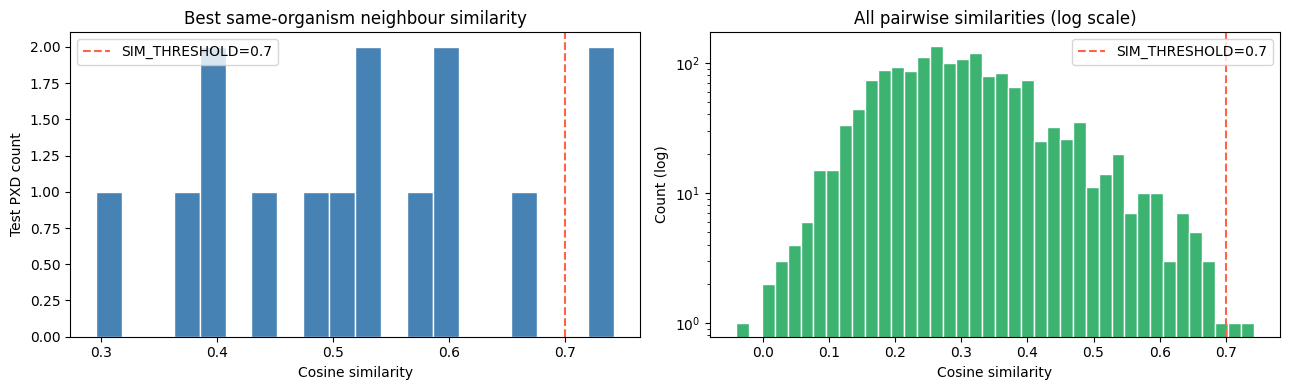

2/15 test PXDs have a same-organism neighbour ≥ 0.7 similarity

=== Per-PXD top same-organism neighbour ===
  PXD004010 (9606 (Homo sapiens)   ) → PXD004143  sim=0.721
  PXD016436 (                      ) → PXD001819  sim=0.585
  PXD019519 (9606 (Homo sapiens)   ) → PXD010429  sim=0.536
  PXD025663 (9606 (Homo sapiens)   ) → PXD010603  sim=0.601
  PXD040582 (9606 (Homo sapiens)   ) → PXD018357  sim=0.482
  PXD050621 (562 (Escherichia coli)) → PXD006195  sim=0.403
  PXD061009 (                      ) → PXD010357  sim=0.531
  PXD061090 (10116 (Rattus norvegic) → PXD019113  sim=0.295
  PXD061136 (10090 (Mus musculus)  ) → PXD002870  sim=0.586
  PXD061195 (                      ) → PXD018117  sim=0.657
  PXD061285 (10090 (Mus musculus)  ) → PXD012143  sim=0.373
  PXD062014 (9606 (Homo sapiens)   ) → PXD004242  sim=0.436
  PXD062469 (9606 (Homo sapiens)   ) → PXD005554  sim=0.504
  PXD062877 (10090 (Mus musculus)  ) → PXD019113  sim=0.404
  PXD064564 (9606 (Homo sapiens)   ) → PXD002395  si

In [78]:
import matplotlib.pyplot as plt

best_same_org_sims = []
for qi, test_pxd in enumerate(test_pxds_with_text):
    query_org = test_organisms.get(test_pxd, '')
    row = sim_matrix[qi]
    for j in row.argsort()[::-1]:
        anchor_pxd = train_pxds_with_text[j]
        anchor_org = train_organisms.get(anchor_pxd, '')
        if not query_org or not anchor_org or query_org == anchor_org:
            best_same_org_sims.append(row[j])
            break
    else:
        best_same_org_sims.append(0.0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(best_same_org_sims, bins=20, color='steelblue', edgecolor='white')
axes[0].axvline(SIM_THRESHOLD, color='tomato', linestyle='--',
                label=f'SIM_THRESHOLD={SIM_THRESHOLD}')
axes[0].set_title('Best same-organism neighbour similarity')
axes[0].set_xlabel('Cosine similarity')
axes[0].set_ylabel('Test PXD count')
axes[0].legend()

# Full matrix distribution
flat = sim_matrix.flatten()
axes[1].hist(flat, bins=40, color='mediumseagreen', edgecolor='white', log=True)
axes[1].axvline(SIM_THRESHOLD, color='tomato', linestyle='--',
                label=f'SIM_THRESHOLD={SIM_THRESHOLD}')
axes[1].set_title('All pairwise similarities (log scale)')
axes[1].set_xlabel('Cosine similarity')
axes[1].set_ylabel('Count (log)')
axes[1].legend()

plt.tight_layout()
plt.show()

above = sum(s >= SIM_THRESHOLD for s in best_same_org_sims)
print(f'{above}/{len(best_same_org_sims)} test PXDs have a same-organism neighbour '
      f'≥ {SIM_THRESHOLD} similarity')

print('\n=== Per-PXD top same-organism neighbour ===')
for qi, (test_pxd, sim) in enumerate(zip(test_pxds_with_text, best_same_org_sims)):
    row = sim_matrix[qi]
    query_org = test_organisms.get(test_pxd, '(unknown)')
    # find the actual anchor
    best_anchor = '(none)'
    for j in row.argsort()[::-1]:
        ap = train_pxds_with_text[j]
        ao = train_organisms.get(ap, '')
        if not query_org or not ao or query_org == ao:
            best_anchor = ap
            break
    org_short = str(query_org)[:22]
    print(f'  {test_pxd} ({org_short:<22}) → {best_anchor}  sim={sim:.3f}')